# **Autoencoders**

## **Building Blocks of Autoencoders**  
*   Encoder
*   Decoder
*   Latent Space  ▶ Compressed Representation


## **Significance of Autoencoders**
*   Feature Compression
*   Unsupervised Feature Learning


## **Types of Autoencoders**
* **Shallow Autoencoders:** A shallow autoencoder is a simple artificial neural network used for unsupervised learning that contains only one hidden layer (also known as the bottleneck or latent space) between its input and output layers.
* **Deep Autoencoders:** A deep autoencoder is an unsupervised neural network with multiple layers (deep) that learns to compress data into a lower-dimensional representation (encoding) and then reconstruct it back to the original (decoding), aiming to capture the most essential features for efficient data compression, dimensionality reduction, and anomaly detection, effectively learning a compact code for complex inputs like images or text.
* **Sparse Autoencoders:** A Sparse Autoencoder (SAE) is a type of neural network that learns efficient data representations by adding a sparsity penalty, forcing only a few hidden neurons to activate for any given input, rather than all of them. This prevents the network from simply copying input-output data (overfitting) and instead compels it to extract meaningful, robust features, often resulting in interpretable components (concepts) that represent useful patterns in the data.  
* **Denoising Autoencoders:** A Denoising Autoencoder (DAE) is a type of neural network that learns to remove noise from corrupted data by reconstructing the original, clean input from a corrupted version, effectively acting as a powerful filter for images, audio, or text, and learning robust data features by preventing simple memorization. Unlike standard autoencoders, it's trained with intentionally added noise (like Gaussian or salt-and-pepper noise) to its input, but then tries to recover the original, clean data, forcing it to learn essential patterns rather than just replicating details.  

<center>

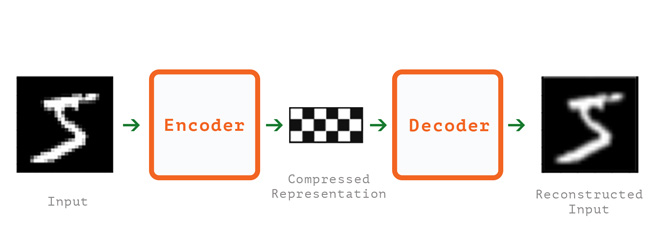

</center>

<h2>
<b>Identity Mapping:</b>
<h2>
<center>
$x = f(x)$
</center>
<h2>
But learning identity mapping. may not help to extract important features from the dataset.
Therefore, we introduce the approximated learning of the identity function.
The equation will be:
<h2>
<center>
$x ≈ f(x)$
</center>

In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
import random
import numpy as np

* MNIST

In [ ]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])
# Download the MNIST Dataset
train_set = datasets.MNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)

# DataLoader is used to load the dataset
# for training
train_loader = torch.utils.data.DataLoader(dataset = train_set,
                                     batch_size = 32,
                                     shuffle = True)

# for testing
test_set = datasets.MNIST(root = "./data",
                         train = False,
                         download = True,
                         transform = tensor_transform)

test_loader = torch.utils.data.DataLoader(dataset = test_set,
                                     batch_size = 32,
                                     shuffle = True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 141MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 60.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 121MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


* Fashion-MNIST

In [ ]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

# Download the MNIST Dataset
train_set = datasets.FashionMNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)

# DataLoader is used to load the dataset
# for training
train_loader = torch.utils.data.DataLoader(dataset = train_set,
                                     batch_size = 32,
                                     shuffle = True)

# for testing
test_set = datasets.FashionMNIST(root = "./data",
                         train = False,
                         download = True,
                         transform = tensor_transform)

test_loader = torch.utils.data.DataLoader(dataset = test_set,
                                     batch_size = 32,
                                     shuffle = True)


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 340kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.26MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


* Data Visualization

torch.Size([32, 1, 28, 28])
torch.Size([32])


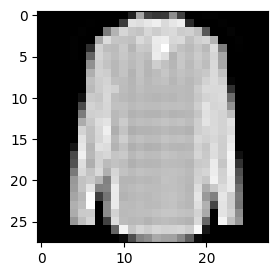

In [ ]:
for image, labels in train_loader:
  print(image.shape)
  print(labels.shape)

  # selecting a random image
  index = random.randint(0, 31)
  img = image[index]
  label = labels[index]
  img = img.reshape(28, 28)

  plt.figure(figsize = (3, 3))
  plt.imshow(img, cmap = 'gray')
  plt.grid(False)

  break

# **Math behind Autoencoders**

<h2>
<b>Input</b>: $X \in \mathbb{R}^{n \times d}$
<h2>
<b>Encoder</b>: $e: X → L \in \mathcal{R}^{n \times l} $ where $l$ is the dimension of the latent space
<h2>
<b>Decoder</b>: $d: L → \tilde{X} $
<h2>
Equation of the tranformation:

<center>
  $\tilde{x} = d(e(x))$
</center>
Equation with parameters:
<center>
$\tilde{x} = W_{d} W_{e} x$
</center>
where $W_{e}, W_{d}$ denotes the lernable weight matrices corresponds to Encoder and Decoder blocks respectively

</h2>


* Encoder Model

In [ ]:
class Encoder(nn.Module):
  def __init__(self, input_dim, hidden_dim):
    super(Encoder, self).__init__()

    self.enc1 = nn.Linear(input_dim, hidden_dim)
    self.act1 = nn.Tanh()

  def forward(self, x):
    x = self.enc1(x)
    x = self.act1(x)
    return x

* Decoder Model

In [ ]:
class Decoder(nn.Module):
  def __init__(self, output_dim, hidden_dim):
    super(Decoder, self).__init__()

    self.dec1 = nn.Linear(hidden_dim, output_dim)
    self.act1 = nn.Sigmoid()

  def forward(self, x):
    x = self.dec1(x)
    x = self.act1(x)
    return x

* Autoencoder Model

In [ ]:
class AutoEnc(nn.Module):
  def __init__(self, input_dim, output_dim, hidden_dim):
    super(AutoEnc, self).__init__()

    # encoder
    self.enc = Encoder(input_dim, hidden_dim)

    # decoder
    self.dec = Decoder(output_dim, hidden_dim)

  def forward(self, x):
    x = self.enc(x)

    # encoded part
    latent_x = x

    x = self.dec(x)

    return x, latent_x

* **Model, Optimizer and Loss function Definition**

* **Loss function:** <u>Mean Squared Loss (MSE)
<center>
$MSE(x, \tilde{x}) = ||x - \tilde{x}||^2$
</center>

In [ ]:
# Model Initialization
model = AutoEnc(28*28, 28*28, 16)

# Validation using MSE Loss function
loss_function = torch.nn.MSELoss()

# Using an Adam OptimiMSE(x,x~)=||x−x~||2zer
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

* Training Phase

In [ ]:
num_epochs = 20
losses = []

# train mode
model.train()

# training of the model
for epoch in range(num_epochs):
  batch_loss = 0.0

  for (image, _) in train_loader:
    # input set
    image = image.reshape(-1, 28*28)

    # output after passing through the autoencoder
    recon, latent_x = model(image)

    loss = loss_function(recon, image)

    # reset the previous gradients
    optimizer.zero_grad()

    # back-propagation alogirthm
    loss.backward()

    # updating the model paramterers
    optimizer.step()

    batch_loss += loss

  # averaging losses of a single batch
  avg_loss = batch_loss / 32

  # accumulating avg loss per batch
  losses.append(avg_loss)

  print(f"Epoch: {epoch+1: 04d}, Loss: {loss: .4f}")

# model saving
torch.save(model.state_dict(), 'fashion-mnist_autoenc.pt')

Epoch:  001, Loss:  0.0160
Epoch:  002, Loss:  0.0183
Epoch:  003, Loss:  0.0180
Epoch:  004, Loss:  0.0157
Epoch:  005, Loss:  0.0177
Epoch:  006, Loss:  0.0214
Epoch:  007, Loss:  0.0160
Epoch:  008, Loss:  0.0183
Epoch:  009, Loss:  0.0166
Epoch:  010, Loss:  0.0190
Epoch:  011, Loss:  0.0182
Epoch:  012, Loss:  0.0191
Epoch:  013, Loss:  0.0193
Epoch:  014, Loss:  0.0191
Epoch:  015, Loss:  0.0151
Epoch:  016, Loss:  0.0187
Epoch:  017, Loss:  0.0211
Epoch:  018, Loss:  0.0206
Epoch:  019, Loss:  0.0218
Epoch:  020, Loss:  0.0208


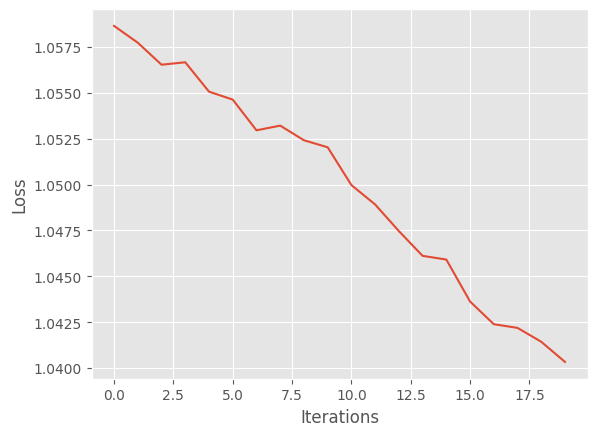

In [ ]:
# Defining the Plot Style
plt.style.use('ggplot')

plt.xlabel('Iterations')
plt.ylabel('Loss')

# plotting training loss
plt.plot([loss.detach().numpy() for loss in losses])

In [ ]:
# loading the saved model from the directory
# model path for mnist dataset
model_path = os.getcwd() + '/fashion-mnist_autoenc.pt'

# model path for mnist dataset
# model_path = os.getcwd() + '/mnist_autoenc.pt'
model.load_state_dict(torch.load(model_path))

# evaluation mode
model.eval()

AutoEnc(
  (enc): Encoder(
    (enc1): Linear(in_features=784, out_features=16, bias=True)
    (act1): Tanh()
  )
  (dec): Decoder(
    (dec1): Linear(in_features=16, out_features=784, bias=True)
    (act1): Sigmoid()
  )
)

* Testing Phase

torch.Size([32, 1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 784])


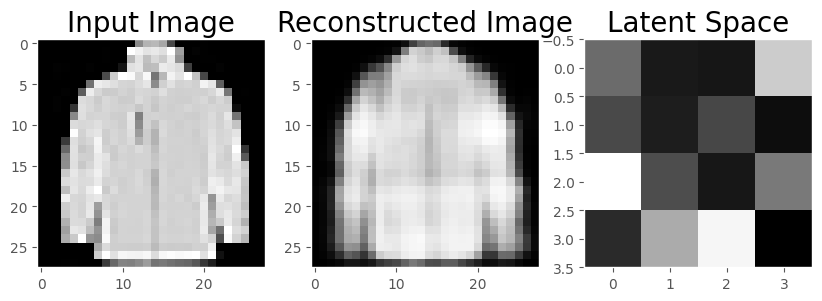

In [ ]:
for (image,_) in test_loader:

  print(image.shape)

  target_img = image[random.randint(0, 31)]
  print(target_img.shape)

  # input should be flattened
  recon, latent_x = model(target_img.reshape(-1, 28*28))
  print(recon.shape)


  # plotting reconstructred image with the original image
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (10, 10))

  target_img = target_img.reshape(28, 28)
  ax1.imshow(target_img, cmap = 'gray')
  ax1.set_title('Input Image', fontsize = 20)
  ax1.grid(False)

  recon = recon.detach().numpy().reshape(28, 28)
  ax2.imshow(recon, cmap = 'gray')
  ax2.set_title('Reconstructed Image', fontsize = 20)
  ax2.grid(False)

  latent_x = latent_x.detach().numpy().reshape(4, 4)
  ax3.imshow(latent_x, cmap = 'gray')
  ax3.set_title('Latent Space', fontsize = 20)
  ax3.grid(False)

  break

* Output Visualization

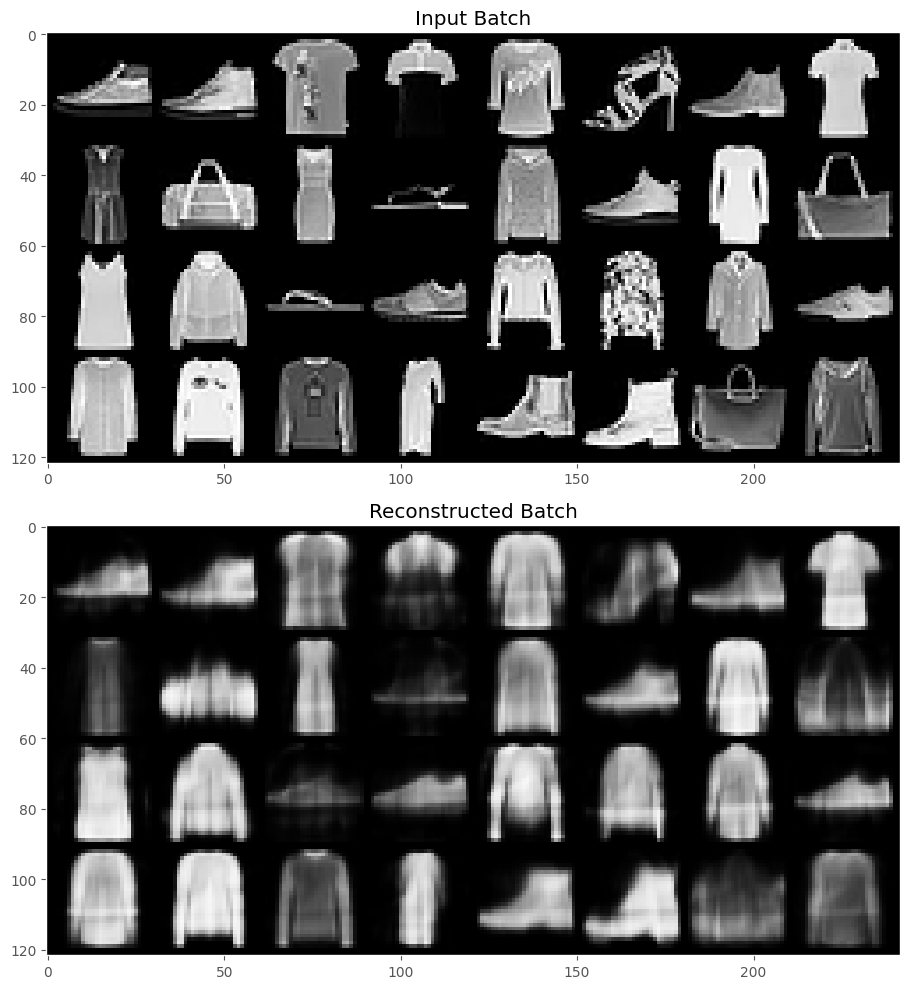

In [ ]:
for image, label in test_loader:

  image = image.reshape(-1, 28*28)
  recon, latent_x = model(image)
  # print(image.shape)
  # print(recon.shape)

  fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10, 10))

  # takes input (B, C, H, W)
  # paddding = 2 (default)
  # images in a row  = 8
  input_set = torchvision.utils.make_grid(image.reshape(-1, 1, 28, 28)).detach().numpy()

  # print(input_set.shape)
  # (C, H, W)
  input_set = np.transpose(input_set, (1,2,0))
  # print("After transpose ", input_set.shape)

  # format is (H, W, C)
  ax1.imshow(input_set)
  ax1.title.set_text('Input Batch')
  ax1.grid(False)

  recon_set = torchvision.utils.make_grid(recon.reshape(-1, 1, 28, 28)).detach().numpy()
  # print(full_set.shape)
  ax2.imshow(np.transpose(recon_set, (1,2,0)))
  ax2.title.set_text('Reconstructed Batch')
  ax2.grid(False)

  # padding between subplots
  fig.tight_layout()

  break

  # 9 padding  = (9 * 2) + (28 * 8) = 242 (Row)
  # 5 paddings = (2 * 5) + (28 * 4) = 122 (Column)

In [ ]:
x = np.ones((1, 2, 3, 5))

# np.transpose(x).shape

np.transpose(x, (1, 3, 2, 0)).shape


(2, 5, 3, 1)

# **Deep Autoencoders**

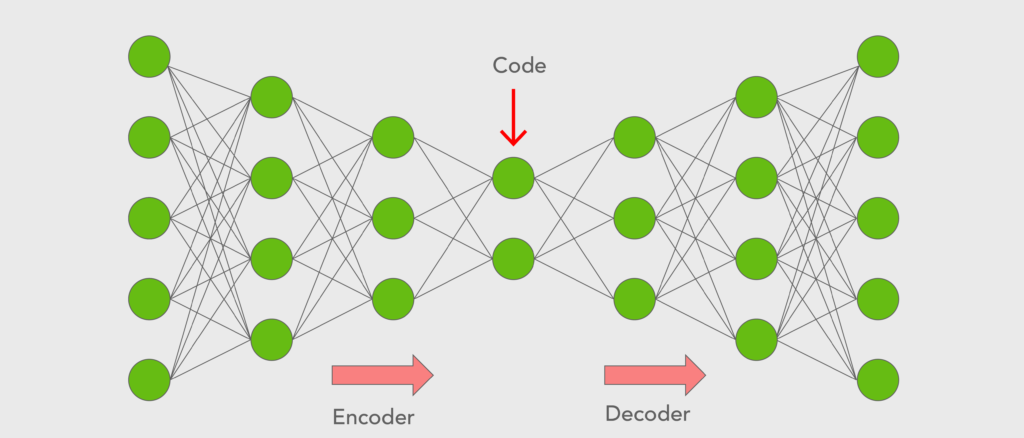



In [ ]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
import random
import numpy as np
import os

* MNIST Dataset

In [ ]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])
# Download the MNIST Dataset
train_set = datasets.MNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)

# DataLoader is used to load the dataset
# for training
train_loader = torch.utils.data.DataLoader(dataset = train_set,
                                     batch_size = 32,
                                     shuffle = True)

# for testing
test_set = datasets.MNIST(root = "./data",
                         train = False,
                         download = True,
                         transform = tensor_transform)

test_loader = torch.utils.data.DataLoader(dataset = test_set,
                                     batch_size = 32,
                                     shuffle = True)


* Fashion-MNIST Dataset

In [ ]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])
# Download the MNIST Dataset
train_set = datasets.FashionMNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)

# DataLoader is used to load the dataset
# for training
train_loader = torch.utils.data.DataLoader(dataset = train_set,
                                     batch_size = 32,
                                     shuffle = True)

# for testing
test_set = datasets.FashionMNIST(root = "./data",
                         train = False,
                         download = True,
                         transform = tensor_transform)

test_loader = torch.utils.data.DataLoader(dataset = test_set,
                                     batch_size = 32,
                                     shuffle = True)


torch.Size([32, 1, 28, 28])
torch.Size([32])


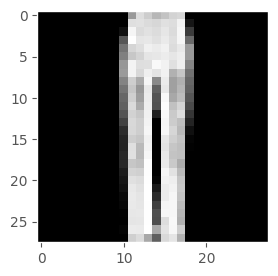

In [ ]:
for image, labels in train_loader:

  print(image.shape)
  print(labels.shape)

  index = random.randint(0, 31)
  img = image[index]
  img = img.reshape(28, 28)

  plt.figure(figsize = (3, 3))
  plt.imshow(img, cmap = 'gray')
  plt.grid(False)
  break

* Encoder Model

In [ ]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    # five hidden layers
    self.enc_1 = torch.nn.Linear(28 * 28, 128)
    self.enc_2 = torch.nn.Linear(128, 64)
    self.enc_3 = torch.nn.Linear(64, 32)
    self.enc_4 = torch.nn.Linear(32, 16)
    self.enc_5 = torch.nn.Linear(16, 8)

  def forward(self, x):
    x = F.relu(self.enc_1(x))
    x = F.relu(self.enc_2(x))
    x = F.relu(self.enc_3(x))
    x = F.relu(self.enc_4(x))
    x = torch.tanh(self.enc_5(x))
    return x


* Decoder Model

In [ ]:
class Decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.dec_1 = torch.nn.Linear(8, 16)
    self.dec_2 = torch.nn.Linear(16, 32)
    self.dec_3 = torch.nn.Linear(32, 64)
    self.dec_4 = torch.nn.Linear(64, 128)
    self.dec_5 = torch.nn.Linear(128, 28 * 28)

  def forward(self, x):
    x = F.relu(self.dec_1(x))
    x = F.relu(self.dec_2(x))
    x = F.relu(self.dec_3(x))
    x = F.relu(self.dec_4(x))
    x = self.dec_5(x)
    x = torch.sigmoid(x)
    return x


In [ ]:
class Deep_AE(torch.nn.Module):
	def __init__(self):
		super().__init__()
		self.enc = Encoder()
		self.dec = Decoder()

	def forward(self, input):
		latent_x = self.enc(input)
		recon = self.dec(latent_x)
		return recon


In [ ]:
# Model Initialization
model = Deep_AE()

# Validation using MSE Loss function
loss_function = torch.nn.MSELoss()

# Using an Adam Optimizer with lr = 0.1
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
num_epochs = 20
losses = []

model.train()

for epoch in range(num_epochs):
	batch_loss = 0.0
	for (image, _) in train_loader:

		# Reshaping the image to (-1, 784)
		image = image.reshape(-1, 28*28)

		# Output of Autoencoder
		reconstructed = model(image)

		# Calculating the loss function
		loss = loss_function(reconstructed, image)

		# The gradients are set to zero,
		# the the gradient is computed and stored.
		# .step() performs parameter update
		optimizer.zero_grad()
		loss.backward()
		optimizer.step()

		# Storing the losses in a list for plotting
		batch_loss += loss

	avg_loss = batch_loss / 32
	losses.append(avg_loss)

	print(f"Epoch: {epoch+1: 04d}, Loss: {loss: .4f}")

torch.save(model.state_dict(), 'deep_ae_fashion-mnist.pt')

Epoch:  001, Loss:  0.0357
Epoch:  002, Loss:  0.0256
Epoch:  003, Loss:  0.0212
Epoch:  004, Loss:  0.0267
Epoch:  005, Loss:  0.0257
Epoch:  006, Loss:  0.0231
Epoch:  007, Loss:  0.0198
Epoch:  008, Loss:  0.0184
Epoch:  009, Loss:  0.0181
Epoch:  010, Loss:  0.0191
Epoch:  011, Loss:  0.0224
Epoch:  012, Loss:  0.0235
Epoch:  013, Loss:  0.0195
Epoch:  014, Loss:  0.0174
Epoch:  015, Loss:  0.0156
Epoch:  016, Loss:  0.0216
Epoch:  017, Loss:  0.0203
Epoch:  018, Loss:  0.0182
Epoch:  019, Loss:  0.0197
Epoch:  020, Loss:  0.0202


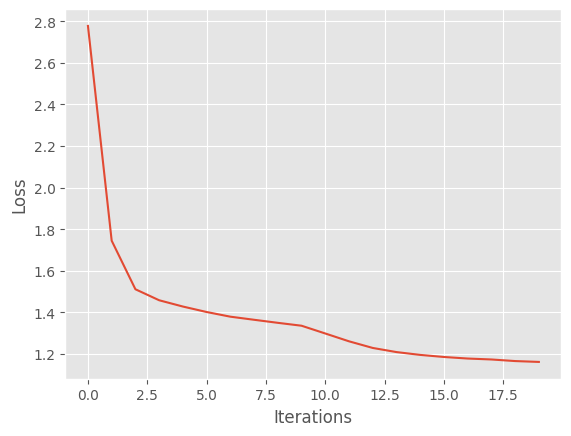

In [ ]:
# Defining the Plot Style
plt.style.use('ggplot')
plt.xlabel('Iterations')
plt.ylabel('Loss')

plt.plot([loss.detach().numpy() for loss in losses])

In [ ]:
model_path = os.getcwd() + '/deep_ae_fashion-mnist.pt'
# model_path = os.getcwd() + '/saved_models/deep_ae_mnist.pt'

model.load_state_dict(torch.load(model_path))
model.eval()

Deep_AE(
  (enc): Encoder(
    (enc_1): Linear(in_features=784, out_features=128, bias=True)
    (enc_2): Linear(in_features=128, out_features=64, bias=True)
    (enc_3): Linear(in_features=64, out_features=32, bias=True)
    (enc_4): Linear(in_features=32, out_features=16, bias=True)
    (enc_5): Linear(in_features=16, out_features=8, bias=True)
  )
  (dec): Decoder(
    (dec_1): Linear(in_features=8, out_features=16, bias=True)
    (dec_2): Linear(in_features=16, out_features=32, bias=True)
    (dec_3): Linear(in_features=32, out_features=64, bias=True)
    (dec_4): Linear(in_features=64, out_features=128, bias=True)
    (dec_5): Linear(in_features=128, out_features=784, bias=True)
  )
)

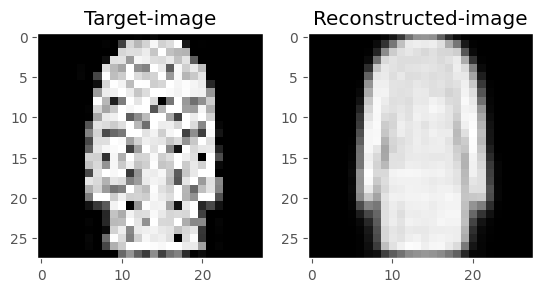

In [ ]:
for (image,_) in test_loader:

  # print(image.shape)

  target_img = image[random.randint(0, 31)]
  # target_img = 1 - target_img
  # print(target_img.shape)

  recon = model(target_img.reshape(-1, 28*28))

  # print(recon.shape)
  # plotting reconstructred image with the original image
  fig, (ax1, ax2) = plt.subplots(1, 2)

  target_img = target_img.reshape(28, 28)
  ax1.imshow(target_img, cmap = 'gray')
  ax1.set_title('Target-image')
  ax1.grid(False)

  recon = recon.detach().numpy().reshape(28, 28)
  ax2.imshow(recon, cmap = 'gray')
  ax2.set_title('Reconstructed-image')
  ax2.grid(False)

  break

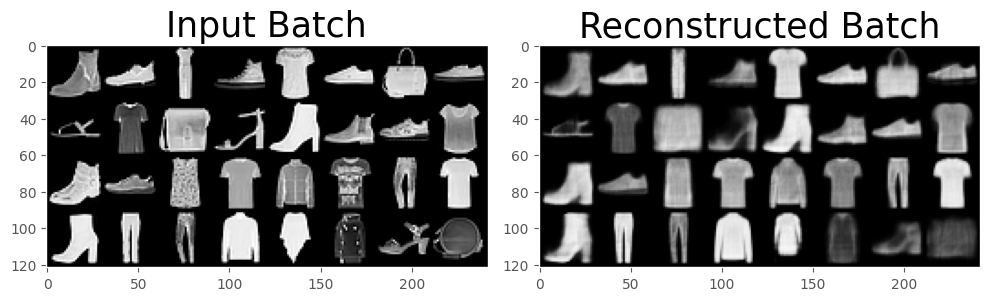

In [ ]:
import numpy as np

for image, label in test_loader:

  image = image.reshape(-1, 28*28)
  recon = model(image)
  # print(image.shape)
  # print(recon.shape)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 10))

  input_set = torchvision.utils.make_grid(image.reshape(-1, 1, 28, 28)).detach().numpy()
  # print(full_set.shape)
  ax1.imshow(np.transpose(input_set, (1,2,0)), cmap = 'gray')
  ax1.set_title('Input Batch', size = 25)
  ax1.grid(False)

  recon_set = torchvision.utils.make_grid(recon.reshape(-1, 1, 28, 28)).detach().numpy()
  # print(full_set.shape)
  ax2.imshow(np.transpose(recon_set, (1,2,0)), cmap = 'gray')
  ax2.set_title('Reconstructed Batch', size = 25)
  ax2.grid(False)

  # padding between subplots
  fig.tight_layout()

  break

In [ ]:
params_list = list(model.parameters())
# print(params_list)

for name, params in model.named_parameters():
  print(name, "  ", params.shape)
  # print(params.shape)

enc.enc_1.weight    torch.Size([128, 784])
enc.enc_1.bias    torch.Size([128])
enc.enc_2.weight    torch.Size([64, 128])
enc.enc_2.bias    torch.Size([64])
enc.enc_3.weight    torch.Size([32, 64])
enc.enc_3.bias    torch.Size([32])
enc.enc_4.weight    torch.Size([16, 32])
enc.enc_4.bias    torch.Size([16])
enc.enc_5.weight    torch.Size([8, 16])
enc.enc_5.bias    torch.Size([8])
dec.dec_1.weight    torch.Size([16, 8])
dec.dec_1.bias    torch.Size([16])
dec.dec_2.weight    torch.Size([32, 16])
dec.dec_2.bias    torch.Size([32])
dec.dec_3.weight    torch.Size([64, 32])
dec.dec_3.bias    torch.Size([64])
dec.dec_4.weight    torch.Size([128, 64])
dec.dec_4.bias    torch.Size([128])
dec.dec_5.weight    torch.Size([784, 128])
dec.dec_5.bias    torch.Size([784])


# Sparse Autoencoders
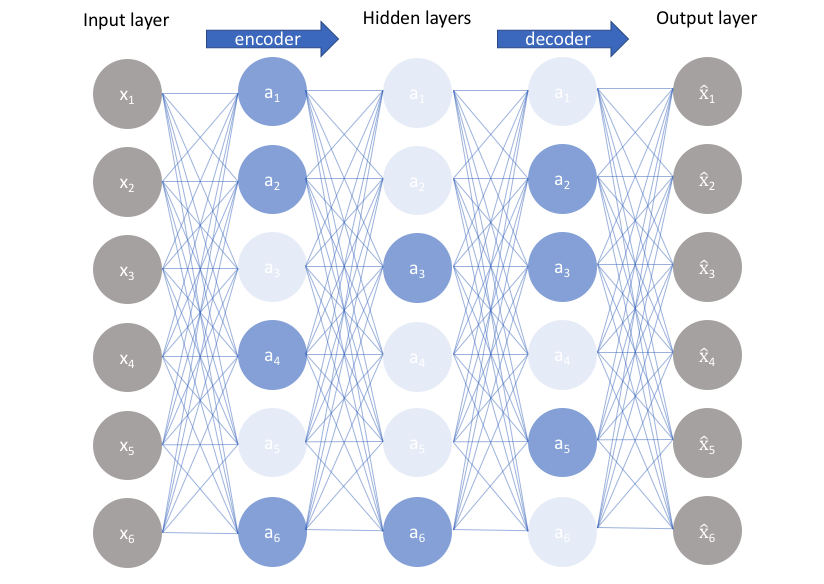

**Utility**
*   Sparsity learns better representation
*   Sensitive to the inputs

<u><b>Loss Function:</b></u>
<center>
  $Loss(x, \tilde{x}) = MSE(x, \tilde{x}) + Regularizer$
</center>

<b> $L_1$ vs $L_2$ Penalty </b>
* We know, $L_1 = ||W||$.
* The gradient of $L_1$ is either $+1$ or $-1$. Then $W$ will move towards zero by the step size $\pm 1$.
* The gradient will be zero when $w = 0$
* Again $L_2 = ||W||^2$.
* The gradient of $L_2 = 2W$. Then $W$ will move towards zero slowly but never becomes zero.

In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import random
from PIL import Image
import numpy as np

* MNIST Dataset

In [ ]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])
# Download the MNIST Dataset
train_set = datasets.MNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)

# DataLoader is used to load the dataset
# for training
train_loader = torch.utils.data.DataLoader(dataset = train_set,
                                     batch_size = 32,
                                     shuffle = True)

# for testing
test_set = datasets.MNIST(root = "./data",
                         train = False,
                         download = True,
                         transform = tensor_transform)

test_loader = torch.utils.data.DataLoader(dataset = test_set,
                                     batch_size = 32,
                                     shuffle = True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.73MB/s]


torch.Size([32, 1, 28, 28])
torch.Size([32])


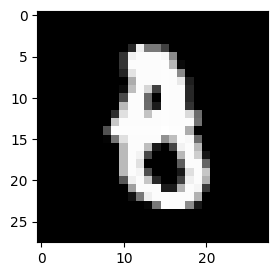

In [ ]:
for image, labels in train_loader:
  print(image.shape)
  print(labels.shape)

  # selecting a random image
  index = random.randint(0, 31)
  img = image[index]
  label = labels[index]
  img = img.reshape(28, 28)
  plt.figure(figsize = (3, 3))
  plt.imshow(img, cmap = 'gray')
  plt.grid(False)

  break

In [ ]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.enc_1 = torch.nn.Linear(28 * 28, 128)
    self.enc_2 = torch.nn.Linear(128, 64)
    self.enc_3 = torch.nn.Linear(64, 32)
    self.enc_4 = torch.nn.Linear(32, 16)
    self.enc_5 = torch.nn.Linear(16, 8)

  def forward(self, x):
    x = F.relu(self.enc_1(x))
    x = F.relu(self.enc_2(x))
    x = F.relu(self.enc_3(x))
    x = F.relu(self.enc_4(x))
    x = F.relu(self.enc_5(x))
    return x


In [ ]:
class Decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.dec_1 = torch.nn.Linear(8, 16)
    self.dec_2 = torch.nn.Linear(16, 32)
    self.dec_3 = torch.nn.Linear(32, 64)
    self.dec_4 = torch.nn.Linear(64, 128)
    self.dec_5 = torch.nn.Linear(128, 28 * 28)

  def forward(self, x):
    x = F.relu(self.dec_1(x))
    x = F.relu(self.dec_2(x))
    x = F.relu(self.dec_3(x))
    x = F.relu(self.dec_4(x))
    x = torch.sigmoid(self.dec_5(x))
    return x


In [ ]:
class Sparse_AutoEnc(nn.Module):
  def __init__(self):
    super(Sparse_AutoEnc, self).__init__()
    self.enc = Encoder()
    self.dec = Decoder()

  def forward(self, x):
    x = self.enc(x)
    latent_x = x
    x = self.dec(x)
    return x, latent_x

In [ ]:
# Model Initialization
model = Sparse_AutoEnc()

# Validation using MSE Loss function
loss_function = torch.nn.MSELoss()

# Using an Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
model_children = list(model.children())
print(model_children)

[Encoder(
  (enc_1): Linear(in_features=784, out_features=128, bias=True)
  (enc_2): Linear(in_features=128, out_features=64, bias=True)
  (enc_3): Linear(in_features=64, out_features=32, bias=True)
  (enc_4): Linear(in_features=32, out_features=16, bias=True)
  (enc_5): Linear(in_features=16, out_features=8, bias=True)
), Decoder(
  (dec_1): Linear(in_features=8, out_features=16, bias=True)
  (dec_2): Linear(in_features=16, out_features=32, bias=True)
  (dec_3): Linear(in_features=32, out_features=64, bias=True)
  (dec_4): Linear(in_features=64, out_features=128, bias=True)
  (dec_5): Linear(in_features=128, out_features=784, bias=True)
)]


In [ ]:
print(model)

Sparse_AutoEnc(
  (enc): Encoder(
    (enc_1): Linear(in_features=784, out_features=128, bias=True)
    (enc_2): Linear(in_features=128, out_features=64, bias=True)
    (enc_3): Linear(in_features=64, out_features=32, bias=True)
    (enc_4): Linear(in_features=32, out_features=16, bias=True)
    (enc_5): Linear(in_features=16, out_features=8, bias=True)
  )
  (dec): Decoder(
    (dec_1): Linear(in_features=8, out_features=16, bias=True)
    (dec_2): Linear(in_features=16, out_features=32, bias=True)
    (dec_3): Linear(in_features=32, out_features=64, bias=True)
    (dec_4): Linear(in_features=64, out_features=128, bias=True)
    (dec_5): Linear(in_features=128, out_features=784, bias=True)
  )
)


 **L1 Penalty**

$L_1 = \sum_{i} ||W||$ where $W_i$ is the activations of $i^{th}$ hidden layer.

$L_1$ penalty ensures sparsity by activating specific neurons of the autoencoder.

In [ ]:
# estimating L1 penalty
def sparse_loss(model_children, images):
    loss = 0.0
    inputs = images

    for i in range(len(model_children)):
      # print(i+1, " ", model_children[i])
      # activation of the hidden layers
      inputs = F.relu((model_children[i](inputs)))

      loss += torch.mean(torch.abs(inputs))

    return loss

In [ ]:
num_epochs = 15
losses = []
lambda_val = 0.001

# train mode
model.train()

# training of the model
for epoch in range(num_epochs):
  batch_loss = 0.0
  for (image, _) in train_loader:

    image = image.reshape(-1, 28*28)

    recon, latent_x = model(image)

    loss = loss_function(recon, image)

    # adding sparsity loss
    l1_penalty = sparse_loss(model_children, image) * lambda_val
    loss += l1_penalty

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_loss += loss

  # averaging losses of a single batch
  avg_loss = batch_loss / 32

  # accumulating avg loss per batch
  losses.append(avg_loss)

  print(f"Epoch: {epoch+1: 04d}, Loss: {avg_loss: .4f}")

# model saving
torch.save(model.state_dict(), 'model.pt')

Epoch:  001, Loss:  3.2666
Epoch:  002, Loss:  2.4208
Epoch:  003, Loss:  2.2456
Epoch:  004, Loss:  2.1707
Epoch:  005, Loss:  2.1135
Epoch:  006, Loss:  2.0746
Epoch:  007, Loss:  2.0490
Epoch:  008, Loss:  1.9999
Epoch:  009, Loss:  1.9500
Epoch:  010, Loss:  1.9065
Epoch:  011, Loss:  1.8651
Epoch:  012, Loss:  1.8403
Epoch:  013, Loss:  1.8258
Epoch:  014, Loss:  1.8730
Epoch:  015, Loss:  1.8523


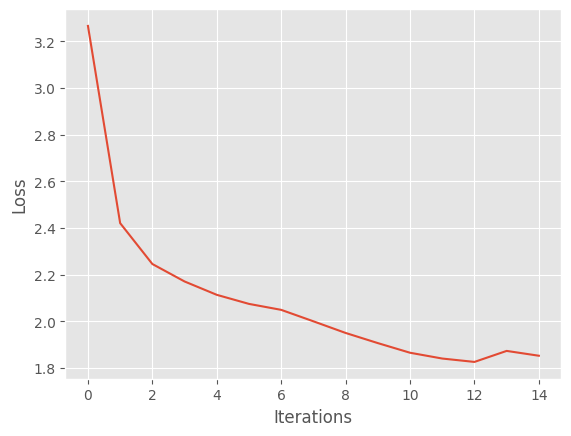

In [ ]:
# Defining the Plot Style
plt.style.use('ggplot')

plt.xlabel('Iterations')
plt.ylabel('Loss')

# plotting training loss
plt.plot([loss.detach().numpy() for loss in losses])

In [ ]:
# loading trained model
model_sp = Sparse_AutoEnc()
model = Sparse_AutoEnc()

model_path_sp = os.getcwd() + '/sparse_ae_mnist.pt'
model_sp.load_state_dict(torch.load(model_path_sp))

model_path = os.getcwd() + '/no_sparse_ae_mnist.pt'
model.load_state_dict(torch.load(model_path))

# model evaluation mode
model.eval()
model_sp.eval()

Sparse_AutoEnc(
  (enc): Encoder(
    (enc_1): Linear(in_features=784, out_features=128, bias=True)
    (enc_2): Linear(in_features=128, out_features=64, bias=True)
    (enc_3): Linear(in_features=64, out_features=32, bias=True)
    (enc_4): Linear(in_features=32, out_features=16, bias=True)
    (enc_5): Linear(in_features=16, out_features=8, bias=True)
  )
  (dec): Decoder(
    (dec_1): Linear(in_features=8, out_features=16, bias=True)
    (dec_2): Linear(in_features=16, out_features=32, bias=True)
    (dec_3): Linear(in_features=32, out_features=64, bias=True)
    (dec_4): Linear(in_features=64, out_features=128, bias=True)
    (dec_5): Linear(in_features=128, out_features=784, bias=True)
  )
)

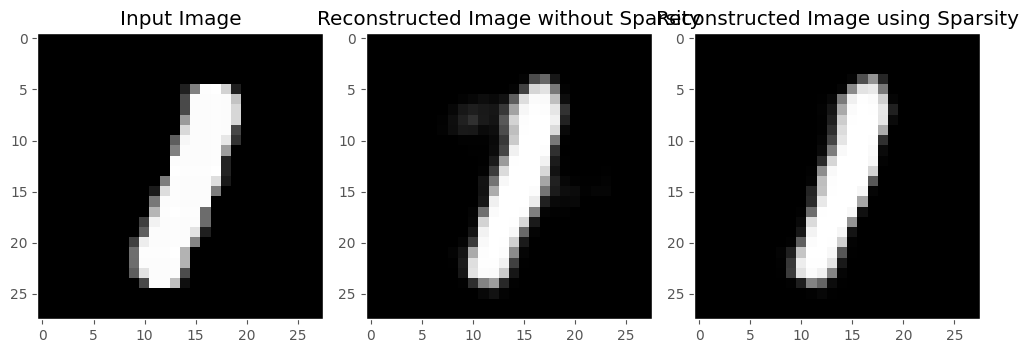

In [ ]:
for (image,_) in test_loader:

  # print(image.shape)

  input_img = image[random.randint(0, 31)]

  # print(target_img.shape)
  input_img = input_img.reshape(-1, 28*28)
  recon, latent_x = model(input_img)
  recon_sp, latent_x_sp = model_sp(input_img)

  # print(recon.shape)

  # plotting reconstructred image with the original image
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 10))

  input_img = input_img.reshape(28, 28)
  ax1.imshow(input_img, cmap = 'gray')
  ax1.grid(False)
  ax1.title.set_text('Input Image')
  # ax1.grid(None)

  recon = recon.detach().numpy().reshape(28, 28)
  ax2.imshow(recon, cmap = 'gray')
  ax2.grid(False)
  ax2.title.set_text('Reconstructed Image without Sparsity')
  # ax2.grid(None)

  recon_sp = recon_sp.detach().numpy().reshape(28, 28)
  ax3.imshow(recon_sp, cmap = 'gray')
  ax3.grid(False)
  ax3.title.set_text('Reconstructed Image using Sparsity')
  # ax3.grid(None)

  fig.tight_layout()

  break

torch.Size([32, 784])
torch.Size([32, 784])


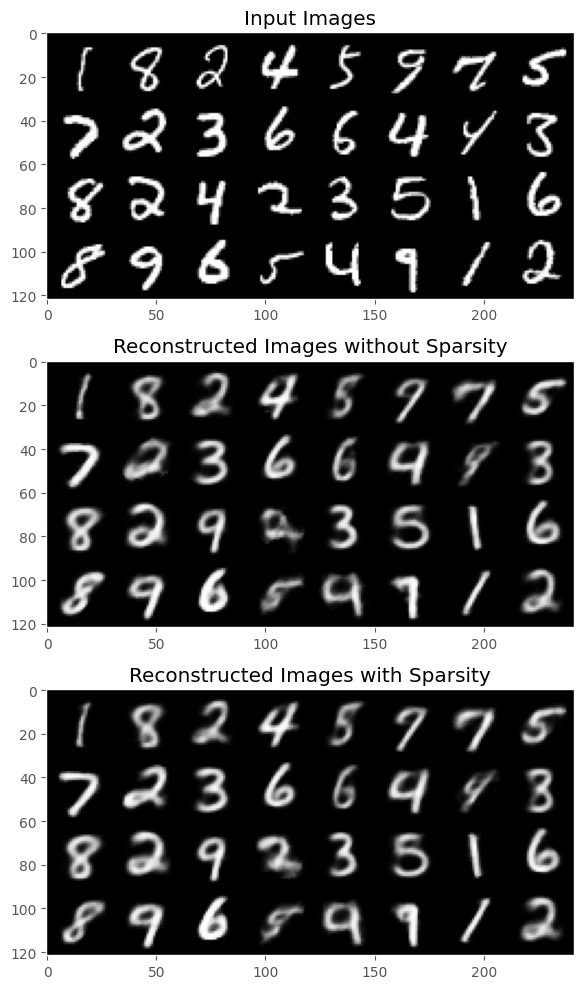

In [ ]:
for image, label in test_loader:

  image = image.reshape(-1, 28*28)
  recon, latent_x = model(image)
  recon_sp, latent_x_sp = model_sp(image)

  print(image.shape)
  print(recon.shape)

  # full_set = torch.cat([image, recon], 0)
  # print(full_set.shape)

  fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (10, 10))

  input_set = torchvision.utils.make_grid(image.reshape(-1, 1, 28, 28)).detach().numpy()
  ax1.imshow(np.transpose(input_set, (1,2,0)), cmap = 'gray')
  ax1.title.set_text('Input Images')
  ax1.grid(False)

  recon_set = torchvision.utils.make_grid(recon.reshape(-1, 1, 28, 28)).detach().numpy()
  ax2.imshow(np.transpose(recon_set, (1,2,0)), cmap = 'gray')
  ax2.title.set_text('Reconstructed Images without Sparsity')
  ax2.grid(False)

  recon_sp_set = torchvision.utils.make_grid(recon_sp.reshape(-1, 1, 28, 28)).detach().numpy()
  ax3.imshow(np.transpose(recon_sp_set, (1,2,0)), cmap = 'gray')
  ax3.title.set_text('Reconstructed Images with Sparsity')
  ax3.grid(False)

  # padding between subplots
  fig.tight_layout()

  break

In [ ]:
# sparse children
sp_model_children = list(model_sp.children())

# without sparse
model_children = list(model.children())

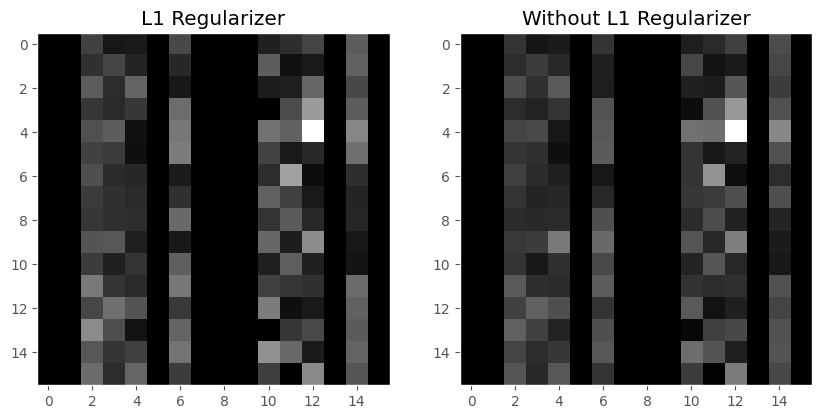

In [ ]:
for image, label in test_loader:

  image = image.reshape(-1, 28*28)
  latent_map_sp = F.relu(sp_model_children[0](image))
  latent_map = F.relu(model_children[0](image))

  latent_map_sp = latent_map_sp.detach().numpy()
  latent_map_sp = latent_map_sp.reshape(16, 16)

  latent_map = latent_map.detach().numpy()
  latent_map = latent_map.reshape(16, 16)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 10))

  ax1.imshow(latent_map_sp, cmap = 'gray')
  ax1.grid(False)
  ax1.set_title('L1 Regularizer')

  ax2.imshow(latent_map, cmap = 'gray')
  ax2.grid(False)
  ax2.set_title('Without L1 Regularizer')

  break

# **Denoising Autoencoders**

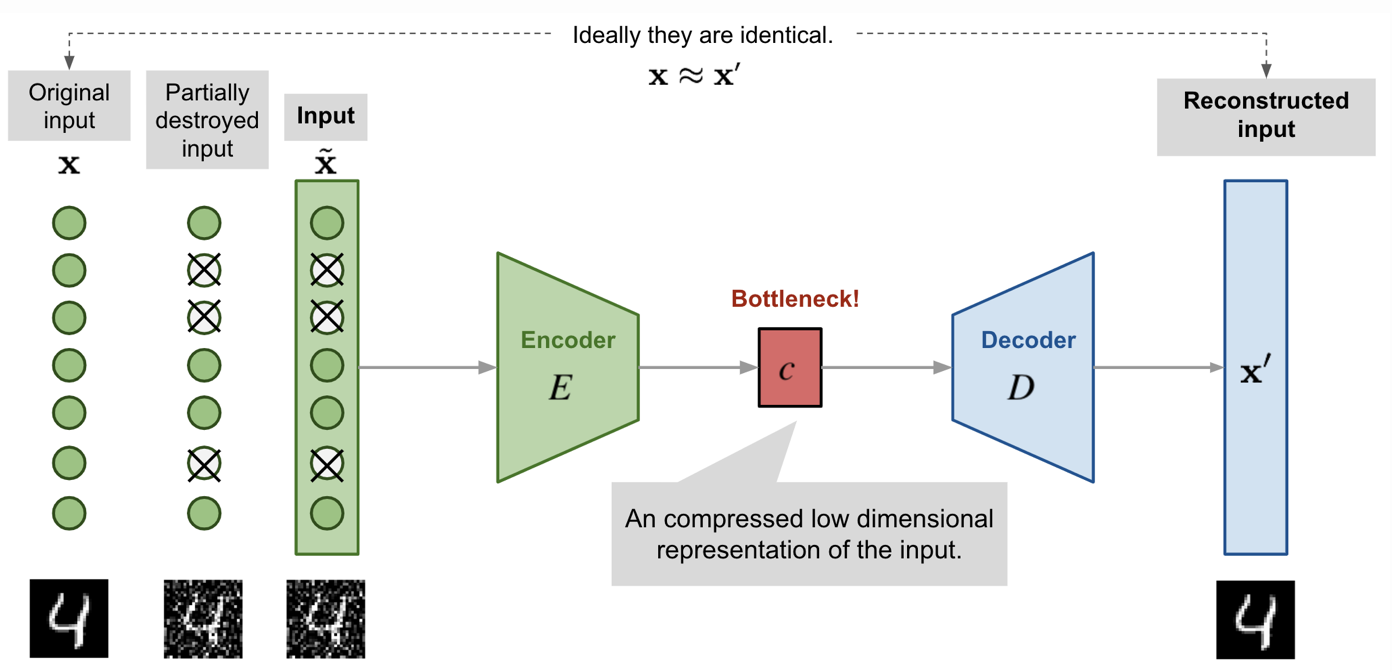


 **Utility**
*   Learns compressed features from the noisy data
*   Reconstruction of data from the noisy input
*   More robust compared to other autoencoders
*   Prevents learning the identity map

In [ ]:
import os
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
import random
import numpy as np

* MNIST Dataset

In [ ]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])
# Download the MNIST Dataset
train_set = datasets.MNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)

# DataLoader is used to load the dataset
# for training
train_loader = torch.utils.data.DataLoader(dataset = train_set,
                                     batch_size = 32,
                                     shuffle = True)

# for testing
test_set = datasets.MNIST(root = "./data",
                         train = False,
                         download = True,
                         transform = tensor_transform)

test_loader = torch.utils.data.DataLoader(dataset = test_set,
                                     batch_size = 32,
                                     shuffle = True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.93MB/s]


* Fashion-MNIST Dataset

In [ ]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])
# Download the MNIST Dataset
train_set = datasets.FashionMNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)

# DataLoader is used to load the dataset
# for training
train_loader = torch.utils.data.DataLoader(dataset = train_set,
                                     batch_size = 32,
                                     shuffle = True)

# for testing
test_set = datasets.FashionMNIST(root = "./data",
                         train = False,
                         download = True,
                         transform = tensor_transform)

test_loader = torch.utils.data.DataLoader(dataset = test_set,
                                     batch_size = 32,
                                     shuffle = True)


100%|██████████| 26.4M/26.4M [00:00<00:00, 120MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.34MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 66.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]


* **Noise Generation**

Standard Gaussian Noise $N(0, 1)$ is used to corrupt the input imgaes

In [ ]:
def add_noise(inputs, noise_factor):
     noisy = inputs + torch.randn_like(inputs) * noise_factor # torch.randn_like(input) makes a tensor same as the size inputs.

     noisy = torch.clamp(noisy, 0., 1.)

     return noisy

torch.Size([32, 1, 28, 28])
torch.Size([32])


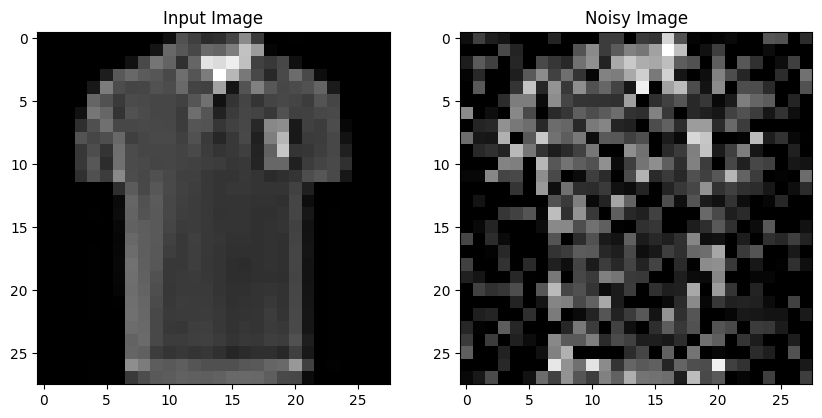

In [ ]:
for image, labels in train_loader:
  print(image.shape)
  print(labels.shape)

  index=random.randint(0,31)
  img=image[index]
  label=image[index]
  img=img.reshape(28,28)

  noisy_img=add_noise(img, 0.2)

  figure, ax=plt.subplots(1,2,figsize=(10,10))
  ax[0].imshow(img,cmap='gray')
  ax[0].grid(False)
  ax[0].title.set_text('Input Image')

  ax[1].imshow(noisy_img,cmap='gray')
  ax[1].grid(False)
  ax[1].title.set_text('Noisy Image')

  break

In [ ]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.enc_1 = torch.nn.Linear(28 * 28, 128)
    self.enc_2 = torch.nn.Linear(128, 64)
    self.enc_3 = torch.nn.Linear(64, 32)
    self.enc_4 = torch.nn.Linear(32, 16)
    self.enc_5 = torch.nn.Linear(16, 8)

  def forward(self, x):
    x = F.relu(self.enc_1(x))
    x = F.relu(self.enc_2(x))
    x = F.relu(self.enc_3(x))
    x = F.relu(self.enc_4(x))
    x = F.relu(self.enc_5(x))
    return x


In [ ]:
class Decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.dec_1 = torch.nn.Linear(8, 16)
    self.dec_2 = torch.nn.Linear(16, 32)
    self.dec_3 = torch.nn.Linear(32, 64)
    self.dec_4 = torch.nn.Linear(64, 128)
    self.dec_5 = torch.nn.Linear(128, 28 * 28)

  def forward(self, x):
    x = F.relu(self.dec_1(x))
    x = F.relu(self.dec_2(x))
    x = F.relu(self.dec_3(x))
    x = F.relu(self.dec_4(x))
    x = torch.sigmoid(self.dec_5(x))
    return x


In [ ]:
class Denoising_AutoEnc(nn.Module):
  def __init__(self):
    super(Denoising_AutoEnc, self).__init__()
    self.enc = Encoder()
    self.dec = Decoder()

  def forward(self, x):
    x = self.enc(x)
    latent_x = x
    x = self.dec(x)
    return x, latent_x

In [ ]:
# Model Initialization
model = Denoising_AutoEnc()

# Validation using MSE Loss function
loss_function = torch.nn.MSELoss()

# Using an Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
num_epochs = 20
losses = []
lambda_val = 0.001

# train mode
model.train()

# training of the model
for epoch in range(num_epochs):
  batch_loss = 0.0
  for (image, _) in train_loader:

    image = image.reshape(-1, 28*28)

    # make it noisy
    noisy_image = add_noise(image, 0.3)

    # model output will be evaluated on noisy images
    recon, latent_x = model(noisy_image)

    # training will br done on original images only
    loss = loss_function(recon, image)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    batch_loss += loss

  # averaging losses of a single batch
  avg_loss = batch_loss / 32

  # accumulating avg loss per batch
  losses.append(avg_loss)

  print(f"Epoch: {epoch+1: 04d}, Loss: {avg_loss: .4f}")

# model saving
torch.save(model.state_dict(), 'denoise_fashion-mnist.pt')

Epoch:  001, Loss:  2.6080
Epoch:  002, Loss:  2.0182
Epoch:  003, Loss:  1.9166
Epoch:  004, Loss:  1.6870
Epoch:  005, Loss:  1.4439
Epoch:  006, Loss:  1.3772
Epoch:  007, Loss:  1.3343
Epoch:  008, Loss:  1.3040
Epoch:  009, Loss:  1.2797
Epoch:  010, Loss:  1.2581
Epoch:  011, Loss:  1.2280
Epoch:  012, Loss:  1.2014
Epoch:  013, Loss:  1.1815
Epoch:  014, Loss:  1.1632
Epoch:  015, Loss:  1.1495
Epoch:  016, Loss:  1.1388
Epoch:  017, Loss:  1.1290
Epoch:  018, Loss:  1.1217
Epoch:  019, Loss:  1.1155
Epoch:  020, Loss:  1.1074


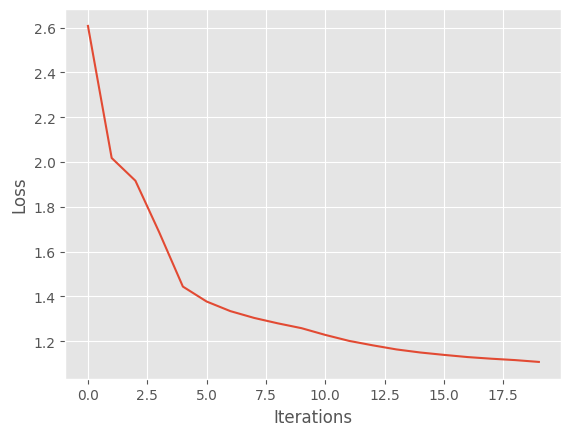

In [ ]:
# Defining the Plot Style
plt.style.use('ggplot')

plt.xlabel('Iterations')
plt.ylabel('Loss')

# plotting training loss
plt.plot([loss.detach().numpy() for loss in losses])

In [ ]:
# model_path = os.getcwd() + '/saved_models/denoise_mnist.pt'
model_path = os.getcwd() + '/denoise_fashion-mnist.pt'
model.load_state_dict(torch.load(model_path))
model.eval()

Denoising_AutoEnc(
  (enc): Encoder(
    (enc_1): Linear(in_features=784, out_features=128, bias=True)
    (enc_2): Linear(in_features=128, out_features=64, bias=True)
    (enc_3): Linear(in_features=64, out_features=32, bias=True)
    (enc_4): Linear(in_features=32, out_features=16, bias=True)
    (enc_5): Linear(in_features=16, out_features=8, bias=True)
  )
  (dec): Decoder(
    (dec_1): Linear(in_features=8, out_features=16, bias=True)
    (dec_2): Linear(in_features=16, out_features=32, bias=True)
    (dec_3): Linear(in_features=32, out_features=64, bias=True)
    (dec_4): Linear(in_features=64, out_features=128, bias=True)
    (dec_5): Linear(in_features=128, out_features=784, bias=True)
  )
)

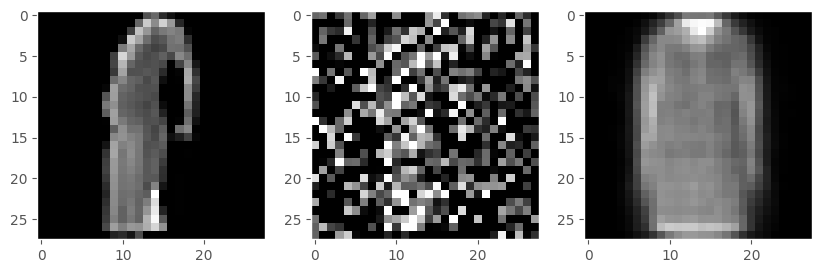

In [ ]:
for (image,_) in test_loader:
  input_image=image[random.randint(0,31)].reshape(-1,28*28)
  noisy_image=add_noise(input_image,0.5)

  recon,latent_x=model(noisy_image)

  fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(10,10))
  input_image=input_image.reshape(28,28)
  ax1.imshow(input_image, cmap = 'gray')
  ax1.grid(False)

  noisy_image = noisy_image.reshape(28, 28)
  ax2.imshow(noisy_image, cmap = 'gray')
  ax2.grid(False)

  recon = recon.detach().numpy().reshape(28, 28)
  ax3.imshow(recon, cmap = 'gray')
  ax3.grid(False)

  break

torch.Size([32, 784])
torch.Size([32, 784])


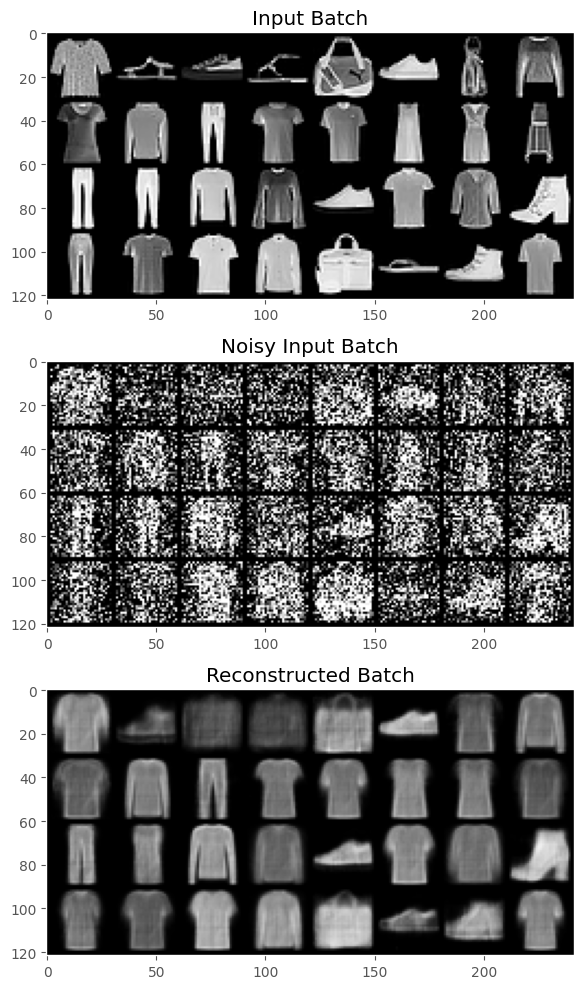

In [ ]:
import numpy as np

for image, label in test_loader:
  image = image.reshape(-1, 28*28)

  # noisy image generation
  noisy_image = add_noise(image, 0.7)

  # noisy images are fed into the model
  recon, latent_x = model(noisy_image)

  print(noisy_image.shape)
  print(recon.shape)

  fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (10, 10))

  input_set = torchvision.utils.make_grid(image.reshape(-1, 1, 28, 28)).detach().numpy()
  ax1.imshow(np.transpose(input_set, (1,2,0)), cmap = 'gray')
  ax1.title.set_text('Input Batch')
  ax1.grid(False)

  noisy_set = torchvision.utils.make_grid(noisy_image.reshape(-1, 1, 28, 28)).detach().numpy()
  ax2.imshow(np.transpose(noisy_set, (1,2,0)), cmap = 'gray')
  ax2.title.set_text('Noisy Input Batch')
  ax2.grid(False)

  recon_set = torchvision.utils.make_grid(recon.reshape(-1, 1, 28, 28)).detach().numpy()
  ax3.imshow(np.transpose(recon_set, (1,2,0)), cmap = 'gray')
  ax3.title.set_text('Reconstructed Batch')
  ax3.grid(False)

  # padding between subplots
  fig.tight_layout()

  break

# <h1><u><b>Data Visualization : t-SNE (t-distributed Stochastic Neighborhood Embedding) </b></u></h1>

* **Properties-**

*   Generates low dimensional representation of the high dimensional data
*   Preseves only local similairties.
*   Unsupervised non-linear dimensionality reduction technique

**Why t-sne over PCA?** t-SNE captures non-linear relationships and preserves local neighborhoods, whereas PCA is linear and focuses on global variance.

<center>

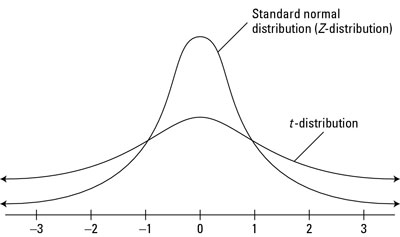

</center>

*   Bell shaped and Symmetric
*   Heavier Tails than Gaussian Distributions - Tends to produce values that fall far from its mean.

<h2>Note : $t-$distribution ensures that all the clusters would not mix up in the middle and which will be difficult to visualize.



In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import matplotlib.cm as cm

In [ ]:
# Transforms images to a PyTorch Tensor
tensor_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])
# Download the MNIST Dataset
train_set = datasets.MNIST(root = "./data",
                         train = True,
                         download = True,
                         transform = tensor_transform)

# DataLoader is used to load the dataset
# for training
train_loader = torch.utils.data.DataLoader(dataset = train_set,
                                     batch_size = 32,
                                     shuffle = True)

# for testing
test_set = datasets.MNIST(root = "./data",
                         train = False,
                         download = True,
                         transform = tensor_transform)

test_loader = torch.utils.data.DataLoader(dataset = test_set,
                                     batch_size = 32,
                                     shuffle = True)


100%|██████████| 9.91M/9.91M [00:01<00:00, 9.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 340kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.68MB/s]


In [ ]:
print("Number of samples for training = ", len(train_set))
print("Number of samples for testing = ", len(test_set))

Number of samples for training =  60000
Number of samples for testing =  10000


In [ ]:
# code for seperate 200 images coresponding to each classes

samples_per_class = 200
num_classes = 10

# total number of samples
num_samples = samples_per_class * num_classes

# stores images from all class labels
images = torch.zeros(num_classes, samples_per_class, 28*28)
print("Shape of the 'images': ",images.shape)

# counter checks whether number of samples of a class is not exceeded its count
counter = [0 for i in range(10)]

# collecting images from the teain set
for i in range(num_samples):

  # print(train_set[i][0].shape, "  ", train_set[i][1])
  l = train_set[i][1]

  if counter[l] < samples_per_class:

    images[int(l)][counter[l]] = train_set[i][0].reshape(28*28)
    counter[l] += 1

  if len(counter) == num_samples:
    break

Shape of the 'images':  torch.Size([10, 200, 784])


In [ ]:
images = images.reshape(2000, 784)
images.shape

torch.Size([2000, 784])

* Apply t-SNE algorithm

In [ ]:
# embedding into 2-D space
# n_components = > dimension in which the points will be embedded
# random_state => reproduces the output through the whole program

model_tsne = TSNE(n_components = 2, random_state = 30)

# applying the model on the input and you will get the desired embedding
embed_x = model_tsne.fit_transform(images)

In [ ]:
print("Shape of embedded features = ", embed_x.shape)

Shape of embedded features =  (2000, 2)


In [ ]:
colors = cm.rainbow(np.linspace(0, 1, 20))
print(colors)
# This line of code generates an array of 20 distinct colors. np.linspace(0, 1, 20) creates 20 evenly spaced numbers between 0 and 1.
# These numbers are then passed to cm.rainbow(), which is a colormap function from Matplotlib that maps these numerical values to corresponding colors
# in the 'rainbow' spectrum. The resulting array, colors, will contain 20 RGBA color values, typically used for distinguishing different data points in plots.

[[5.00000000e-01 0.00000000e+00 1.00000000e+00 1.00000000e+00]
 [3.98039216e-01 1.59475791e-01 9.96795325e-01 1.00000000e+00]
 [2.96078431e-01 3.14869589e-01 9.87201840e-01 1.00000000e+00]
 [1.86274510e-01 4.73093557e-01 9.69796936e-01 1.00000000e+00]
 [8.43137255e-02 6.07538946e-01 9.47177357e-01 1.00000000e+00]
 [2.54901961e-02 7.34844967e-01 9.16033601e-01 1.00000000e+00]
 [1.27450980e-01 8.33602385e-01 8.81012194e-01 1.00000000e+00]
 [2.37254902e-01 9.16033601e-01 8.36989108e-01 1.00000000e+00]
 [3.39215686e-01 9.68276041e-01 7.90532412e-01 1.00000000e+00]
 [4.49019608e-01 9.96795325e-01 7.34844967e-01 1.00000000e+00]
 [5.50980392e-01 9.96795325e-01 6.78235117e-01 1.00000000e+00]
 [6.60784314e-01 9.68276041e-01 6.12420203e-01 1.00000000e+00]
 [7.62745098e-01 9.16033601e-01 5.47219547e-01 1.00000000e+00]
 [8.72549020e-01 8.33602385e-01 4.73093557e-01 1.00000000e+00]
 [9.74509804e-01 7.34844967e-01 4.01101535e-01 1.00000000e+00]
 [1.00000000e+00 6.07538946e-01 3.20710236e-01 1.000000

* t-SNE visualization on MNIST Dataset

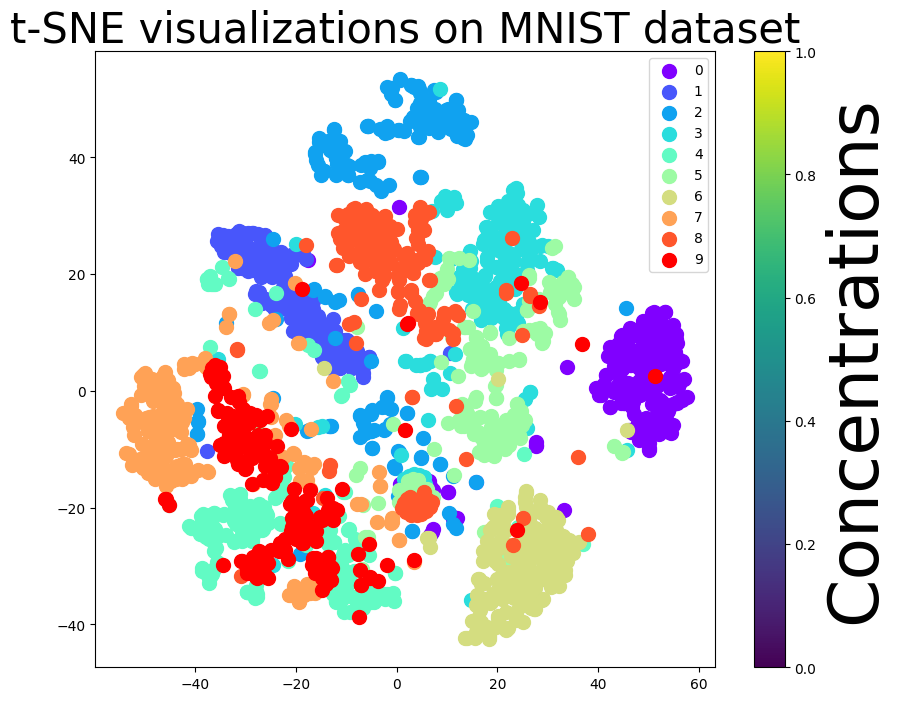

In [ ]:
# generatinh custom colors for different class labels
colors = cm.rainbow(np.linspace(0, 1, 10))
# print(colors)

# fixing figure size
plt.figure(figsize=(10, 8))

for c in range(num_classes):

  plt.scatter(embed_x[samples_per_class * c:samples_per_class * (c+1), 0],
              embed_x[samples_per_class * c:samples_per_class * (c+1), 1],
              s = 100,
              color = colors[c],
              label = c)

cbar = plt.colorbar(orientation = 'vertical')

# # setting color bar title
cbar.set_label(label = "Concentrations", size = 50)

# cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
# cbar.set_ticklabels(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])

# providing title of the plot
plt.title("t-SNE visualizations on MNIST dataset", fontsize = 30)
plt.legend()
plt.show()